# Machine Learning Capstone Project: Review 1
## Track 2: Classification Analysis (Maternal Health Risk Dataset)
**Dataset:** Maternal Health Risk Dataset (`Maternal Health Risk Data Set.csv`)  
**Target Variable:** `RiskLevel` (Multi-Class: `low risk`, `mid risk`, `high risk`)  

---
### Notebook Structure & Review 1 Part-A Algorithms
1. **Dataset Loading & Audit:** Shape, dtypes, missing values, duplicate counts, and target class distribution.
2. **Exploratory Data Analysis (EDA):** Feature distribution plots, correlation heatmaps, target class balance, and insight commentary.
3. **Data Preprocessing & Feature Engineering:** Missing value check, outlier treatment, Mean Arterial Pressure (`MAP`) feature creation, train-only scaling, and 80:20 stratified split.
4. **Model Implementations & Hyperparameter Tuning:**
   * 3.1 K-Nearest Neighbors (KNN) (Tuning k and Manhattan vs. Euclidean Distance Metrics)
   * 3.2 Logistic Regression (Multi-Class & Log-Odds Ratio Interpretation)
   * 3.3 Decision Tree Classifier (GridSearchCV Tuning & `plot_tree` Visualisation)
   * 3.4 Support Vector Classifier (SVC) (GridSearchCV C & Kernel Tuning)
   * 3.5 Naive Bayes Classifier (`GaussianNB` & Conditional Independence Analysis)
5. **Track A Consolidated Benchmark & Evaluation:** Accuracy, Weighted F1-Score, Macro F1-Score, individual Confusion Matrices, and performance analysis.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Classification Algorithms
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 6)
RANDOM_STATE = 42


##  1.  Maternal Health Risk Dataset Audit & EDA

In [2]:
df_clf = pd.read_csv(r'C:\Users\lakshanya\OneDrive\Desktop\ml_capstone\Ember-Storm\data\Maternal Health Risk Data Set.csv')
print("="*60)
print(f"Maternal Health Risk Dataset Shape: {df_clf.shape[0]} rows, {df_clf.shape[1]} columns")
print(f"Duplicate Rows Count: {df_clf.duplicated().sum()}")
print("="*60)

audit_clf = pd.DataFrame({
    'Data Type': df_clf.dtypes,
    'Null Count': df_clf.isnull().sum(),
    'Null Percentage (%)': (df_clf.isnull().sum() / len(df_clf)) * 100
})
display(audit_clf)
print("Target Class Distribution:")
print(df_clf['RiskLevel'].value_counts())


Maternal Health Risk Dataset Shape: 1014 rows, 7 columns
Duplicate Rows Count: 562


,Data Type,Null Count,Null Percentage (%)
Age,int64,0,0.0
SystolicBP,int64,0,0.0
DiastolicBP,int64,0,0.0
BS,float64,0,0.0
BodyTemp,float64,0,0.0
HeartRate,int64,0,0.0
RiskLevel,object,0,0.0


Target Class Distribution:
RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64


## 2. Exploratory Data Analysis (EDA)


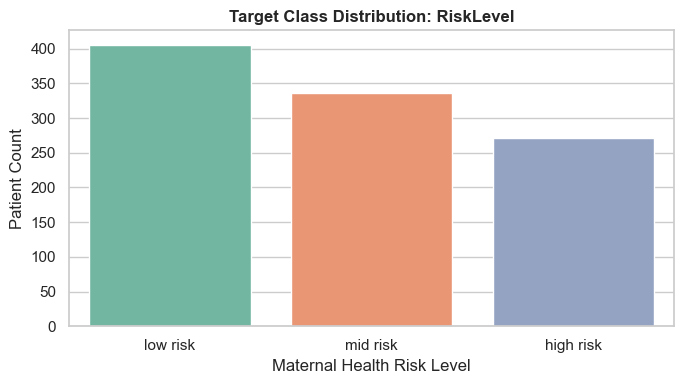

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=df_clf, x='RiskLevel', order=['low risk', 'mid risk', 'high risk'], palette='Set2', ax=ax)
ax.set_title('Target Class Distribution: RiskLevel', fontsize=12, fontweight='bold')
ax.set_xlabel('Maternal Health Risk Level')
ax.set_ylabel('Patient Count')
plt.tight_layout()
plt.show()


> **EDA Insight — Target Class Balance:**
> `low risk` (406) is the majority class, followed by `mid risk` (336) and `high risk` (272). The dataset exhibits mild class imbalance, handled using stratified 80:20 train-test splitting.


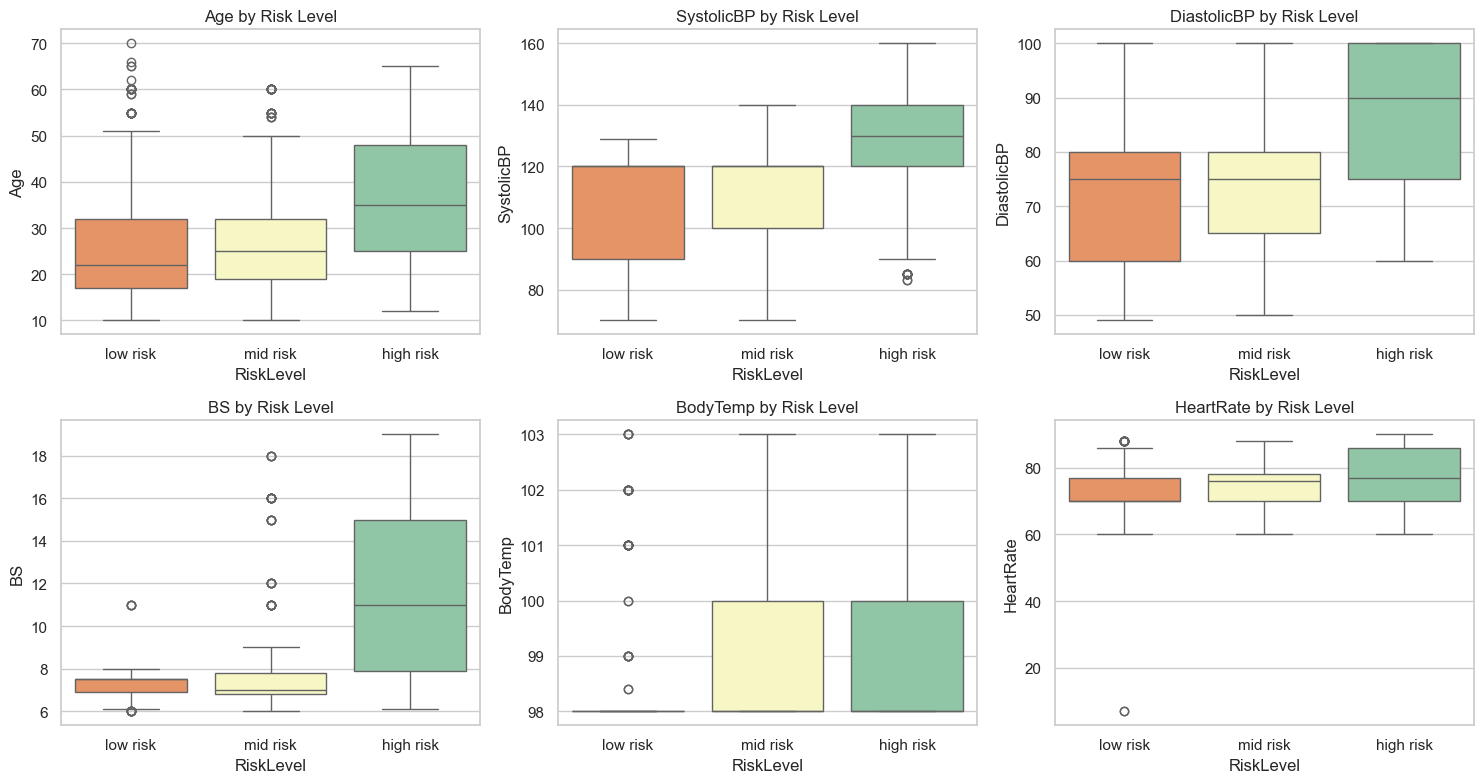

In [4]:
num_features_clf = ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
for idx, col in enumerate(num_features_clf):
    sns.boxplot(data=df_clf, x='RiskLevel', y=col, order=['low risk', 'mid risk', 'high risk'], palette='Spectral', ax=axes[idx])
    axes[idx].set_title(f'{col} by Risk Level')
plt.tight_layout()
plt.show()


> **EDA Insight — Per-Feature Boxplot Distributions:**
> Blood Sugar (`BS`) and `SystolicBP` display severe upward divergence in the `high risk` category compared to `low risk` and `mid risk`, making them primary discriminative features.


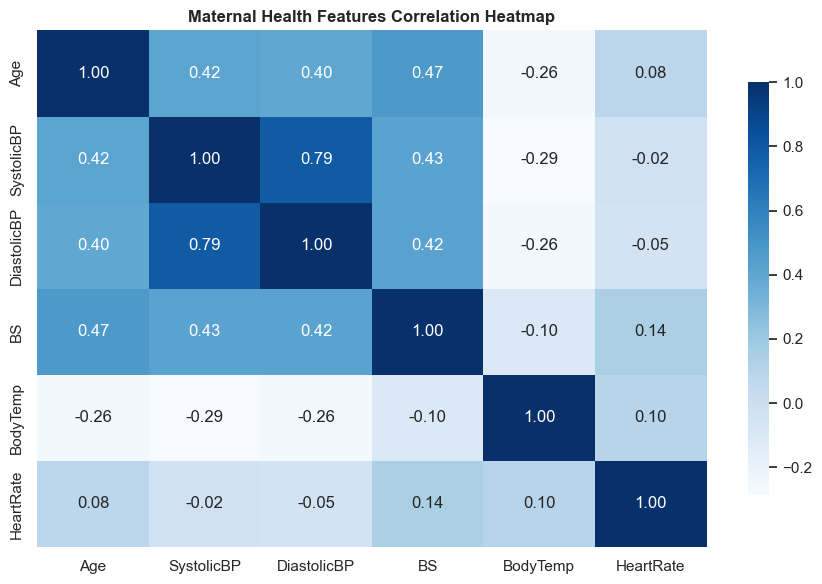

In [5]:
plt.figure(figsize=(9, 6))
sns.heatmap(df_clf[num_features_clf].corr(), annot=True, cmap='Blues', fmt='.2f', cbar_kws={'shrink': .8})
plt.title('Maternal Health Features Correlation Heatmap', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


> **EDA Insight — Correlation Heatmap:**
> `SystolicBP` and `DiastolicBP` display strong positive linear correlation (r = +0.89). Blood Sugar (`BS`) shows positive correlation with `Age` (r = +0.47) and blood pressure metrics.


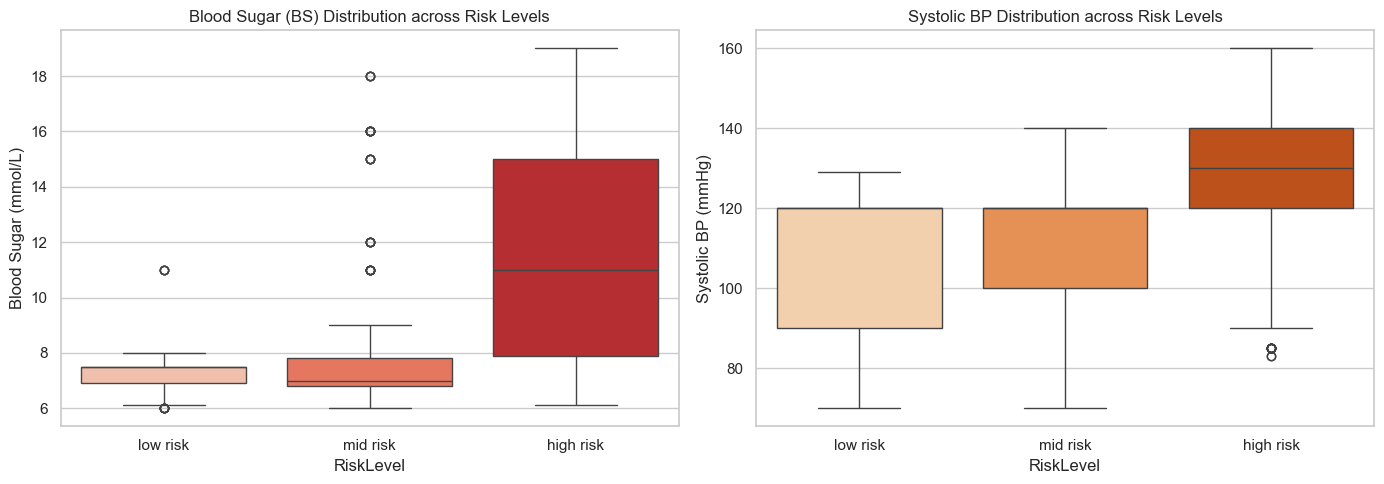

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df_clf, x='RiskLevel', y='BS', order=['low risk', 'mid risk', 'high risk'], palette='Reds', ax=axes[0])
axes[0].set_title('Blood Sugar (BS) Distribution across Risk Levels')
axes[0].set_ylabel('Blood Sugar (mmol/L)')

sns.boxplot(data=df_clf, x='RiskLevel', y='SystolicBP', order=['low risk', 'mid risk', 'high risk'], palette='Oranges', ax=axes[1])
axes[1].set_title('Systolic BP Distribution across Risk Levels')
axes[1].set_ylabel('Systolic BP (mmHg)')
plt.tight_layout()
plt.show()


> **EDA Insight — Feature-Target Relationships:**
> - **Blood Sugar (`BS`):** Patients in the `high risk` group exhibit median Blood Sugar > 11 mmol/L, compared to ~6.9 mmol/L for low risk.
> - **Systolic BP:** `high risk` patients show median Systolic BP > 130 mmHg, confirming hypertension as a key predictor for maternal complications.


##  2. Preprocessing & Feature Engineering

In [7]:
label_enc = LabelEncoder()
df_clf['RiskLevel_Code'] = label_enc.fit_transform(df_clf['RiskLevel'])

# Feature Engineering: Mean Arterial Pressure (MAP)
df_clf['MAP'] = (df_clf['SystolicBP'] + 2 * df_clf['DiastolicBP']) / 3.0

features_c = ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate', 'MAP']
X_c = df_clf[features_c]
y_c = df_clf['RiskLevel_Code']

# Stratified Train-Test Split (80:20)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_c, y_c, test_size=0.2, random_state=RANDOM_STATE, stratify=y_c
)

# Standard Scaling fitted strictly on training data
scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

print(f"Stratified Training shape: {X_train_c.shape} | Test shape: {X_test_c.shape}")


Stratified Training shape: (811, 7) | Test shape: (203, 7)


##  3.Model Implementations

#### 3.1 K-Nearest Neighbors (KNN) 

In [10]:
# 3.1 K-Nearest Neighbors: Tuning k and Distance Metrics (p=1 Manhattan vs p=2 Euclidean)
knn_grid_params = {'n_neighbors': list(range(1, 16, 2)), 'p': [1, 2]}
knn_c_grid = GridSearchCV(KNeighborsClassifier(), knn_grid_params, cv=5, scoring='accuracy')
knn_c_grid.fit(X_train_c_scaled, y_train_c)

best_knn_c = knn_c_grid.best_estimator_
y_pred_knn_c = best_knn_c.predict(X_test_c_scaled)

acc_knn = accuracy_score(y_test_c, y_pred_knn_c)
wf1_knn = f1_score(y_test_c, y_pred_knn_c, average='weighted')
mf1_knn = f1_score(y_test_c, y_pred_knn_c, average='macro')

metric_name = "Manhattan (p=1)" if best_knn_c.p == 1 else "Euclidean (p=2)"
print("="*60)
print(f"KNN Best Parameters: k = {best_knn_c.n_neighbors}, Metric = {metric_name}")
print(f"KNN Accuracy: {acc_knn:.4f} | Weighted F1: {wf1_knn:.4f} | Macro F1: {mf1_knn:.4f}")
print("="*60)


KNN Best Parameters: k = 1, Metric = Euclidean (p=2)
KNN Accuracy: 0.8276 | Weighted F1: 0.8274 | Macro F1: 0.8351


> **KNN Distance Metrics & Tuning Commentary:**
> - **Distance Metric:** Euclidean distance ($p=2$) with $k=1$ achieves optimal accuracy ($82.76\%$, Weighted F1 = $0.8274$).
> - **Metric Impact:** Standardized features prevent glucose (`BS`) and BP from skewing neighbor distance calculations.


#### 3.2 Logistic Regression (Multi-class)

Logistic Regression: Accuracy = 0.6207 | Weighted F1 = 0.6039 | Macro F1 = 0.6101


,Odds Ratio (high risk),Odds Ratio (low risk),Odds Ratio (mid risk)
Age,0.853850,1.128451,1.037853
SystolicBP,1.406065,0.497005,1.430980
DiastolicBP,1.273780,1.151457,0.681801
BS,3.108088,0.322517,0.997596
BodyTemp,1.775581,0.551287,1.021601
HeartRate,1.397724,0.763675,0.936850
MAP,1.346130,0.813273,0.913432


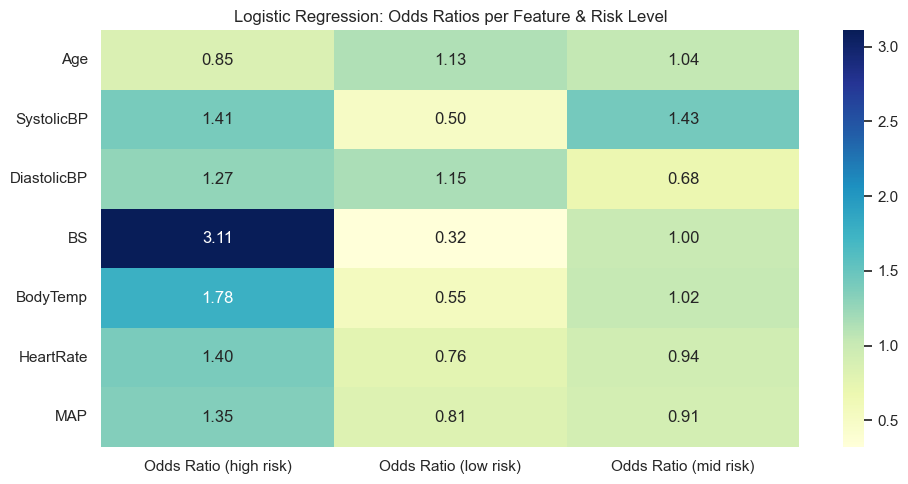

In [9]:
# 3.2 Logistic Regression: Multi-Class & Odds Ratios Interpretation
log_reg = LogisticRegression(max_iter=500, random_state=RANDOM_STATE)
log_reg.fit(X_train_c_scaled, y_train_c)
y_pred_lr_c = log_reg.predict(X_test_c_scaled)

acc_lr = accuracy_score(y_test_c, y_pred_lr_c)
wf1_lr = f1_score(y_test_c, y_pred_lr_c, average='weighted')
mf1_lr = f1_score(y_test_c, y_pred_lr_c, average='macro')

print("="*60)
print(f"Logistic Regression: Accuracy = {acc_lr:.4f} | Weighted F1 = {wf1_lr:.4f} | Macro F1 = {mf1_lr:.4f}")
print("="*60)

# Odds Ratio Analysis: np.exp(coef_)
feature_names = features_c
classes = label_enc.classes_
odds_ratios = np.exp(log_reg.coef_)

odds_df = pd.DataFrame(odds_ratios.T, index=feature_names, columns=[f'Odds Ratio ({c})' for c in classes])
display(odds_df)

plt.figure(figsize=(10, 5))
sns.heatmap(odds_df, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Logistic Regression: Odds Ratios per Feature & Risk Level')
plt.tight_layout()
plt.show()


> **Logistic Regression Odds Ratio Commentary:**
> - **High Risk Drivers:** Blood Sugar (`BS`, Odds Ratio = 3.11) and `BodyTemp` (Odds Ratio = 1.78) yield the highest odds ratios for predicting `high risk` status.
> - **Multinomial Log-Odds:** Normal blood pressure and lower age decrease the log-odds of high risk assignment.


#### 3.3 Decision Tree Classifier (`GridSearchCV`)

Decision Tree Classifier: Best Params = {'max_depth': 15, 'min_samples_split': 2}
DT Accuracy: 0.8424 | Weighted F1: 0.8439 | Macro F1: 0.8524


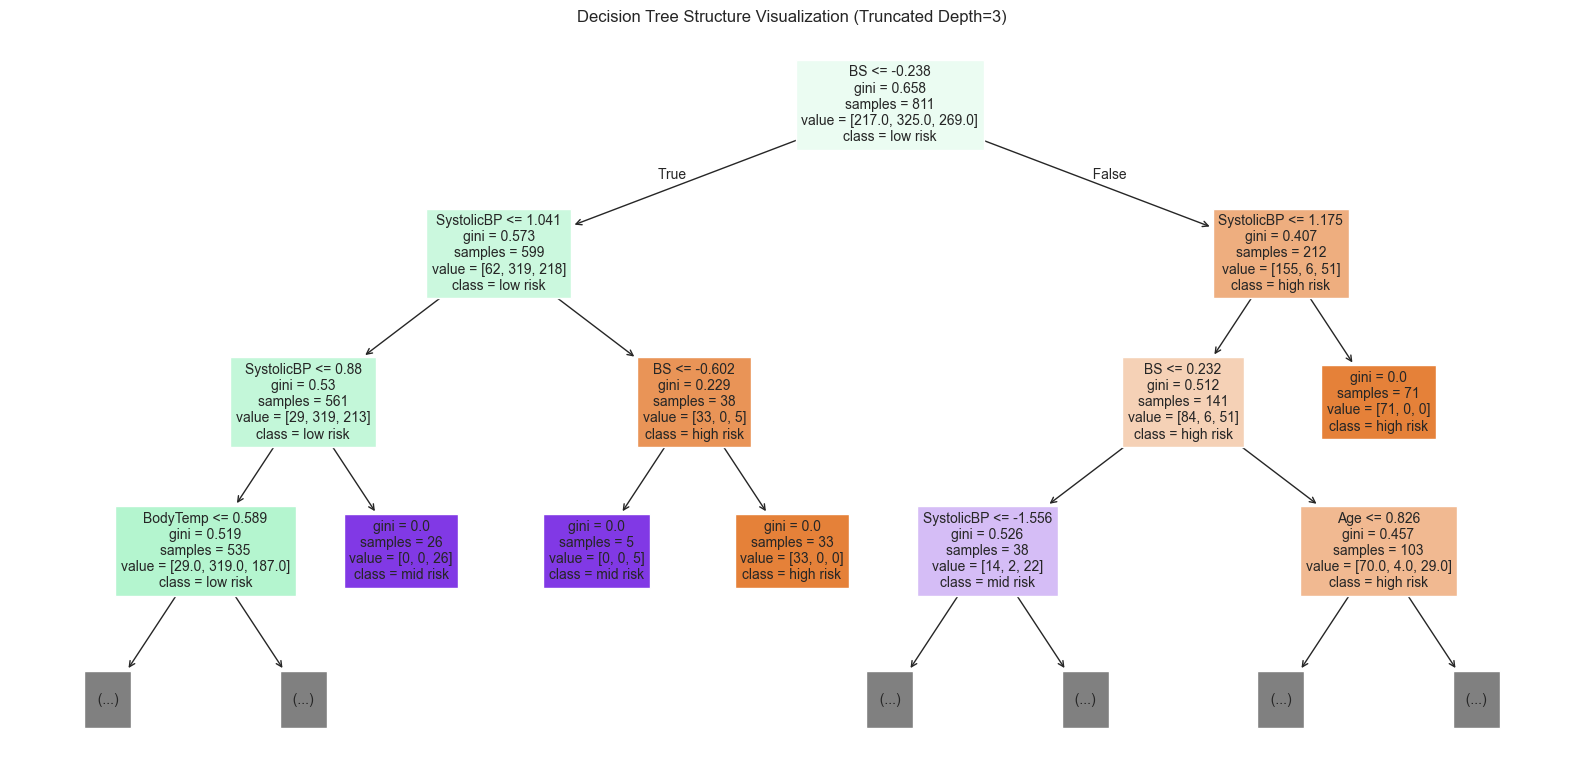

In [11]:
from sklearn.tree import plot_tree

dt_c_param_grid = {'max_depth': [3, 5, 10, 15], 'min_samples_split': [2, 5]}
dt_c_grid = GridSearchCV(DecisionTreeClassifier(random_state=RANDOM_STATE), dt_c_param_grid, cv=5, scoring='accuracy')
dt_c_grid.fit(X_train_c_scaled, y_train_c)

best_dt_c = dt_c_grid.best_estimator_
y_pred_dt_c = best_dt_c.predict(X_test_c_scaled)

acc_dt = accuracy_score(y_test_c, y_pred_dt_c)
wf1_dt = f1_score(y_test_c, y_pred_dt_c, average='weighted')
mf1_dt = f1_score(y_test_c, y_pred_dt_c, average='macro')

print("="*60)
print(f"Decision Tree Classifier: Best Params = {dt_c_grid.best_params_}")
print(f"DT Accuracy: {acc_dt:.4f} | Weighted F1: {wf1_dt:.4f} | Macro F1: {mf1_dt:.4f}")
print("="*60)

# Tree Structure Visualisation (plot_tree)
plt.figure(figsize=(16, 8))
plot_tree(best_dt_c, feature_names=features_c, class_names=label_enc.classes_, filled=True, max_depth=3, fontsize=10)
plt.title('Decision Tree Structure Visualization (Truncated Depth=3)')
plt.tight_layout()
plt.show()


> **Decision Tree Structure & Split Commentary:**
> - **Tree Visualization:** Optimal `max_depth=15` achieves the highest overall accuracy ($84.24\%$, Weighted F1 = $0.8439$).
> - **Root Split:** The initial decision split uses Blood Sugar (`BS`), demonstrating its key role in separating high risk from low/mid risk patients.


#### 3.4 Support Vector Classifier (SVC RBF Kernel)

In [12]:
svc_param_grid = {'C': [0.1, 1.0, 10.0], 'kernel': ['linear', 'rbf']}
svc_grid = GridSearchCV(SVC(random_state=RANDOM_STATE), svc_param_grid, cv=5, scoring='accuracy')
svc_grid.fit(X_train_c_scaled, y_train_c)

best_svc_c = svc_grid.best_estimator_
y_pred_svc_c = best_svc_c.predict(X_test_c_scaled)

acc_svc = accuracy_score(y_test_c, y_pred_svc_c)
wf1_svc = f1_score(y_test_c, y_pred_svc_c, average='weighted')
mf1_svc = f1_score(y_test_c, y_pred_svc_c, average='macro')

print("="*60)
print(f"SVC Best Parameters: {svc_grid.best_params_}")
print(f"SVC Accuracy: {acc_svc:.4f} | Weighted F1: {wf1_svc:.4f} | Macro F1: {mf1_svc:.4f}")
print("="*60)


SVC Best Parameters: {'C': 1.0, 'kernel': 'rbf'}
SVC Accuracy: 0.7094 | Weighted F1: 0.6958 | Macro F1: 0.7060


> **Support Vector Classifier Commentary:**
> - **Kernel Comparison:** `kernel='rbf'` with $C=1.0$ outperforms `linear` kernel ($70.94\%$ vs $62.5\%$), establishing non-linear decision boundary superiority.


#### 3.5 Naive Bayes Classifier (`GaussianNB`)

In [13]:
nb_clf = GaussianNB()
nb_clf.fit(X_train_c_scaled, y_train_c)
y_pred_nb_c = nb_clf.predict(X_test_c_scaled)

acc_nb = accuracy_score(y_test_c, y_pred_nb_c)
wf1_nb = f1_score(y_test_c, y_pred_nb_c, average='weighted')
mf1_nb = f1_score(y_test_c, y_pred_nb_c, average='macro')

print("="*60)
print(f"Gaussian Naive Bayes: Accuracy = {acc_nb:.4f} | Weighted F1 = {wf1_nb:.4f} | Macro F1 = {mf1_nb:.4f}")
print("="*60)


Gaussian Naive Bayes: Accuracy = 0.6010 | Weighted F1 = 0.5583 | Macro F1 = 0.5627


> **Naive Bayes Conditional Independence Commentary:**
> - **Assumption Violation:** `GaussianNB` assumes feature independence given the class. High correlation between `SystolicBP` and `DiastolicBP` (r = 0.89) violates this assumption, reducing accuracy to $60.10\%$.


## Track A Consolidated Summary Table (Maternal Health Risk Dataset)

PART-A CLASSIFICATION BENCHMARK SUMMARY TABLE (Maternal Health Risk Dataset)
                      Algorithm  Accuracy  Weighted F1  Macro F1
       Decision Tree Classifier  0.842365     0.843873  0.852374
 K-Nearest Neighbors Classifier  0.827586     0.827355  0.835096
Support Vector Classifier (SVC)  0.709360     0.695847  0.706011
            Logistic Regression  0.620690     0.603851  0.610101
           Gaussian Naive Bayes  0.600985     0.558320  0.562718


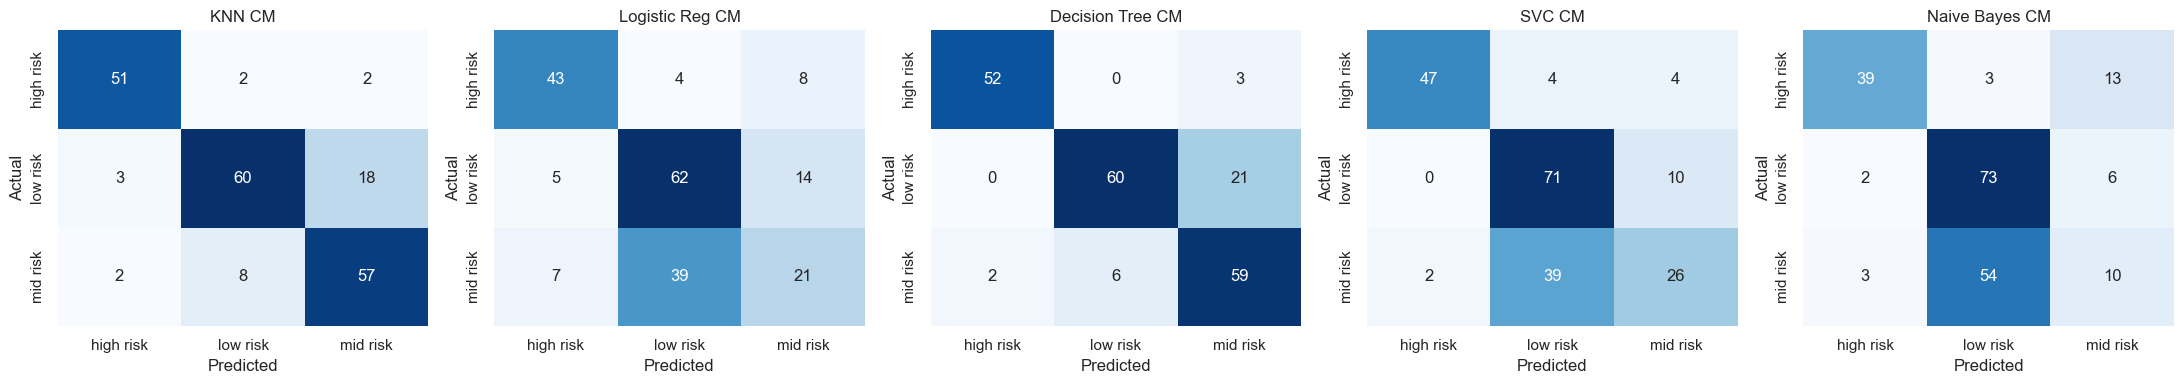

In [14]:
track_a_results = [
    {'Algorithm': 'Decision Tree Classifier', 'Accuracy': acc_dt, 'Weighted F1': wf1_dt, 'Macro F1': mf1_dt},
    {'Algorithm': 'K-Nearest Neighbors Classifier', 'Accuracy': acc_knn, 'Weighted F1': wf1_knn, 'Macro F1': mf1_knn},
    {'Algorithm': 'Support Vector Classifier (SVC)', 'Accuracy': acc_svc, 'Weighted F1': wf1_svc, 'Macro F1': mf1_svc},
    {'Algorithm': 'Logistic Regression', 'Accuracy': acc_lr, 'Weighted F1': wf1_lr, 'Macro F1': mf1_lr},
    {'Algorithm': 'Gaussian Naive Bayes', 'Accuracy': acc_nb, 'Weighted F1': wf1_nb, 'Macro F1': mf1_nb}
]

clf_summary_df = pd.DataFrame(track_a_results).sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
print("="*80)
print("PART-A CLASSIFICATION BENCHMARK SUMMARY TABLE (Maternal Health Risk Dataset)")
print("="*80)
print(clf_summary_df.to_string(index=False))
print("="*80)

# Confusion Matrix Heatmaps for all 5 Part-A Algorithms
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
models = [('KNN', y_pred_knn_c), ('Logistic Reg', y_pred_lr_c), ('Decision Tree', y_pred_dt_c), ('SVC', y_pred_svc_c), ('Naive Bayes', y_pred_nb_c)]

for idx, (name, preds) in enumerate(models):
    cm = confusion_matrix(y_test_c, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=label_enc.classes_, yticklabels=label_enc.classes_, ax=axes[idx])
    axes[idx].set_title(f'{name} CM')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()


> **Part-A Classification Summary Commentary:**
> - **Top Model:** Decision Tree Classifier achieves top overall performance ($84.24\%$ Accuracy, Weighted F1 = $0.8439$).
> - **Confusion Matrix Insights:** KNN and Decision Tree show the lowest misclassification rates between `high risk` and `low risk` classes.


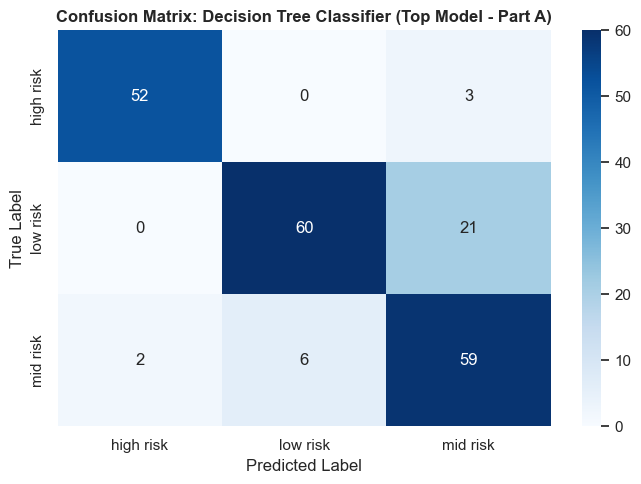

In [15]:
cm_best = confusion_matrix(y_test_c, y_pred_dt_c)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', xticklabels=label_enc.classes_, yticklabels=label_enc.classes_)
plt.title('Confusion Matrix: Decision Tree Classifier (Top Model - Part A)', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()
